<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_14_projectB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

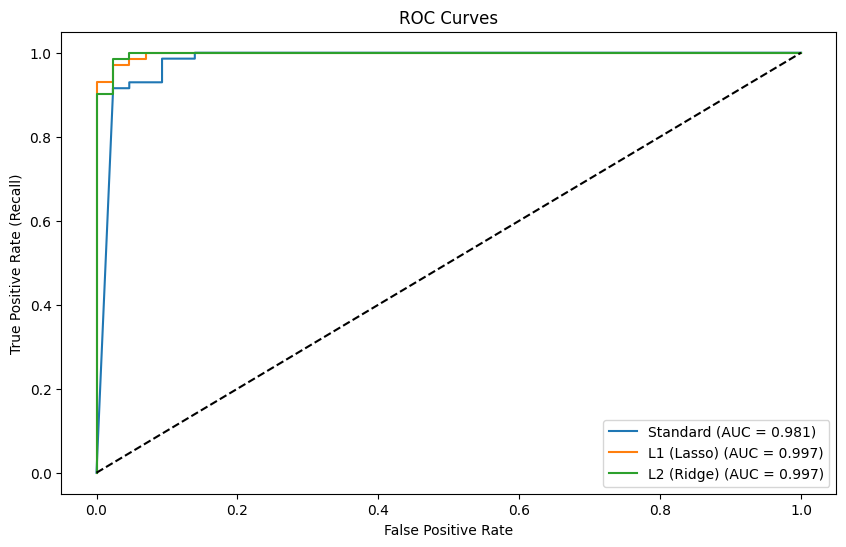


--- Performance Table ---
        Model      AUC
0    Standard  0.98133
1  L1 (Lasso)  0.99738
2  L2 (Ridge)  0.99738

--- Confusion Matrix (Custom Threshold) ---


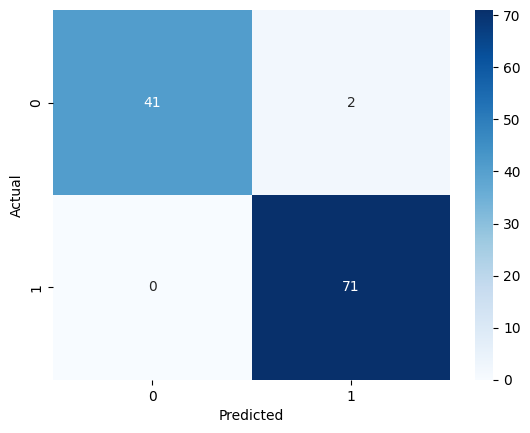

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)

# 1. Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0: Malignant, 1: Benign

# 2. Preprocessing
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is VERY IMPORTANT for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Models: Standard, L1 (Lasso), and L2 (Ridge)
models = {
    "Standard": LogisticRegression(penalty=None),
    "L1 (Lasso)": LogisticRegression(penalty='l1', solver='liblinear', C=0.5),
    "L2 (Ridge)": LogisticRegression(penalty='l2', C=0.5)
}

results = []

# 4. Training and Evaluation
plt.figure(figsize=(10, 6))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    auc = roc_auc_score(y_test, y_probs)
    results.append({"Model": name, "AUC": auc})

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves')
plt.legend()
plt.show()

# 5. Threshold Tuning for Medical Use-Case (Optimize for Recall)
# We want to catch as many Malignant (class 0) cases as possible.
# Note: In this dataset, 'Malignant' is 0, but usually we treat the 'sick' class as 1.
# Let's adjust the threshold to increase sensitivity for class 0.
best_model = models["L2 (Ridge)"]
y_probs_final = best_model.predict_proba(X_test_scaled)[:, 1]

# Lowering the threshold for "Benign" (1) effectively makes us
# more likely to predict "Malignant" (0).
custom_threshold = 0.3
y_pred_custom = (y_probs_final >= custom_threshold).astype(int)

# 6. Final Outputs
print("\n--- Performance Table ---")
print(pd.DataFrame(results))

print("\n--- Confusion Matrix (Custom Threshold) ---")
cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,roc_auc_score,roc_curve,classification_report,precision_recall_curve)

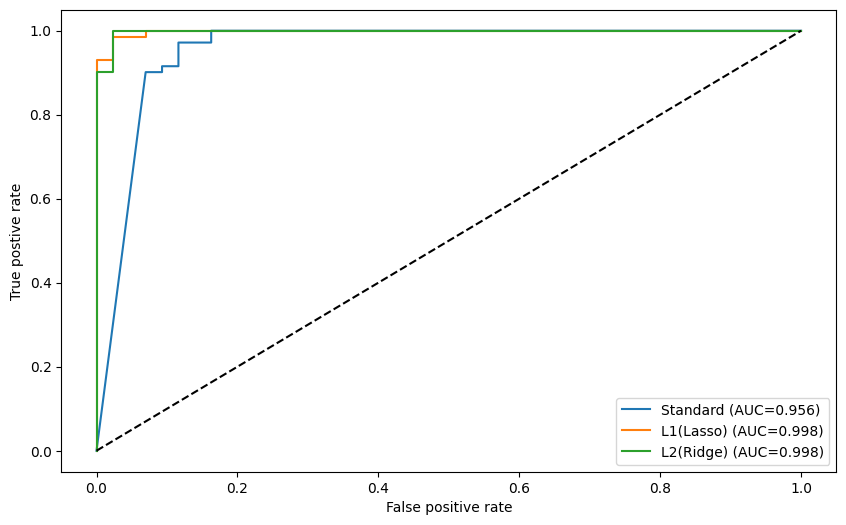

Best Model :L1(Lasso) with AUC:0.9977


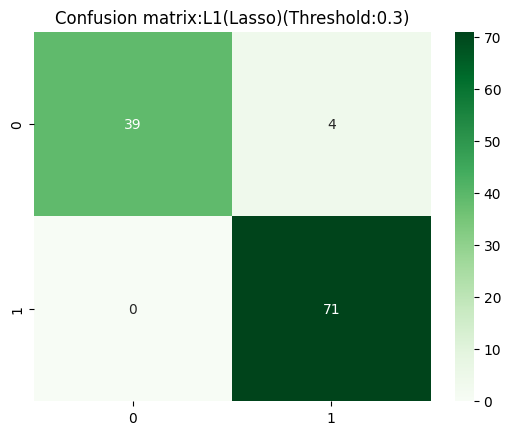

In [17]:
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target #Malignant:0,Benign:1

#Splitting the data into train,test set

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Scaling the data
scale=StandardScaler()
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.fit_transform(X_test)

#Comparing 3 Models

models={
    "Standard":LogisticRegression(penalty=None),
    "L1(Lasso)":LogisticRegression(penalty='l1',solver='liblinear',C=0.5),
    "L2(Ridge)":LogisticRegression(penalty='l2',C=0.5)
}

best_auc=0
best_model_name=""

results=[]

#Training and evaluatin

plt.figure(figsize=(10,6))

for name,model in models.items():
  model.fit(X_train_scale,y_train)
  y_probs=model.predict_proba(X_test_scale)[:,1]
  y_pred=model.predict(X_test_scale)

  auc=roc_auc_score(y_test,y_probs)
  results.append({"Model":name,"AUC":auc})

  if(auc>best_auc):
    best_auc=auc
    best_model_name=name

  #plot roc curve
  fpr,tpr,_=roc_curve(y_test,y_probs)
  plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate")
plt.ylabel("True postive rate")
plt.legend()
plt.show()


print(f"Best Model :{best_model_name} with AUC:{best_auc:.4f}")


#Tuning the best model to optimize for class 0 i.e Malignant class

final_model=models[best_model_name]
y_probs_final=final_model.predict_proba(X_test_scale)[:,1]


custom_threshold=0.3
y_pred_final=(y_probs_final>=custom_threshold).astype(int)


#confusion matrix for the best model

cm=confusion_matrix(y_test,y_pred_final)
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.title(f"Confusion matrix:{best_model_name}(Threshold:{custom_threshold})")
plt.show()





L1(Lasso)
